In [1]:
import sys
import requests
import pandas as pd
import numpy as np
import matplotlib
import ollama
import sentence_transformers
import huggingface_hub
import os
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"
print("Python version:", sys.version)
print("requests version:", requests.__version__)
print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)
print("matplotlib version:", matplotlib.__version__)
print("ollama library version:", ollama.__version__ if hasattr(ollama, "__version__") else "n/a")
print("sentence-transformers version:", sentence_transformers.__version__)
print("huggingface_hub version:", huggingface_hub.__version__)

Python version: 3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]
requests version: 2.32.5
pandas version: 3.0.1
numpy version: 2.4.2
matplotlib version: 3.10.8
ollama library version: n/a
sentence-transformers version: 5.7.0
huggingface_hub version: 1.27.0


In [2]:
# The dashboard does not ship static local data files — per its README, all
# intelligence domains (earthquakes, volcanoes, aircraft, CVEs, etc.) are
# pulled live from public APIs at runtime (The-ProfessorGG, 2026).
# To connect to the same live data the dashboard uses, this notebook queries
# the USGS earthquake feed and NASA EONET volcano feed directly.

import requests
import pandas as pd

# USGS earthquakes - last 24 hours, significant events
usgs_url = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/significant_day.geojson"
usgs_response = requests.get(usgs_url, timeout=15)
usgs_data = usgs_response.json()

earthquake_records = []
for feature in usgs_data.get("features", []):
    props = feature["properties"]
    coords = feature["geometry"]["coordinates"]
    earthquake_records.append({
        "type": "earthquake",
        "place": props.get("place"),
        "magnitude": props.get("mag"),
        "time": props.get("time"),
        "longitude": coords[0],
        "latitude": coords[1]
    })

earthquakes_df = pd.DataFrame(earthquake_records)
print("Earthquake records:", len(earthquakes_df))
earthquakes_df.head()

Earthquake records: 0


""


In [3]:
# NASA EONET volcanic activity feed
eonet_url = "https://eonet.gsfc.nasa.gov/api/v3/categories/volcanoes"
eonet_response = requests.get(eonet_url, timeout=15)
eonet_data = eonet_response.json()

volcano_records = []
for event in eonet_data.get("events", []):
    geometry = event.get("geometry", [])
    coords = geometry[-1]["coordinates"] if geometry else [None, None]
    volcano_records.append({
        "type": "volcano",
        "place": event.get("title"),
        "date": geometry[-1]["date"] if geometry else None,
        "longitude": coords[0],
        "latitude": coords[1]
    })

volcanoes_df = pd.DataFrame(volcano_records)
print("Volcano records:", len(volcanoes_df))
volcanoes_df.head()

Volcano records: 32


,type,place,date,longitude,latitude
0,volcano,"Nevados del Chillan Volcano, Chile",2026-06-15T00:00:00Z,-71.3780,-36.8680
1,volcano,"Telica Volcano, Nicaragua",2026-05-30T00:00:00Z,-86.8400,12.6060
2,volcano,"Ivao Group Volcano, Russia",2026-05-29T00:00:00Z,149.6762,45.7593
3,volcano,"Titan Ridge Volcano, Papua New Guinea",2026-05-28T00:00:00Z,147.7800,-3.0300
4,volcano,"Kikai Volcano, Japan",2026-05-17T00:00:00Z,130.3050,30.7930


In [4]:
# Build a short text description per event, to feed into the models

event_descriptions = []

for _, row in earthquakes_df.iterrows():
    desc = f"Earthquake event: {row['place']}, magnitude {row['magnitude']}."
    event_descriptions.append(desc)

for _, row in volcanoes_df.iterrows():
    desc = f"Volcanic activity event: {row['place']}."
    event_descriptions.append(desc)

print("Total event descriptions built:", len(event_descriptions))
for d in event_descriptions[:5]:
    print("-", d)

Total event descriptions built: 32
- Volcanic activity event: Nevados del Chillan Volcano, Chile.
- Volcanic activity event: Telica Volcano, Nicaragua.
- Volcanic activity event: Ivao Group Volcano, Russia.
- Volcanic activity event: Titan Ridge Volcano, Papua New Guinea.
- Volcanic activity event: Kikai Volcano, Japan.


In [5]:
import ollama

sample_event = event_descriptions[0] if event_descriptions else "Earthquake event: Pacific region, magnitude 6.1."

prompt = f"Summarise this intelligence event in one sentence: {sample_event}"

response_1 = ollama.generate(
    model="llama3.1",
    prompt=prompt,
    options={"temperature": 0}
)["response"]

response_2 = ollama.generate(
    model="llama3.1",
    prompt=prompt,
    options={"temperature": 0}
)["response"]

print("Model A - Run 1:")
print(response_1)
print()
print("Model A - Run 2:")
print(response_2)
print()
print("Outputs match exactly:", response_1.strip() == response_2.strip())

Model A - Run 1:
There has been volcanic activity at Nevados del Chillan Volcano in Chile.

Model A - Run 2:
There has been volcanic activity at Nevados del Chillan Volcano in Chile.

Outputs match exactly: True


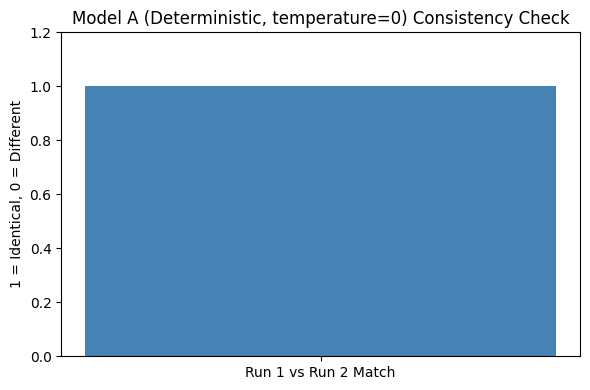

In [6]:
import matplotlib.pyplot as plt

match_result = int(response_1.strip() == response_2.strip())

plt.figure(figsize=(6, 4))
plt.bar(["Run 1 vs Run 2 Match"], [match_result], color="steelblue")
plt.ylim(0, 1.2)
plt.ylabel("1 = Identical, 0 = Different")
plt.title("Model A (Deterministic, temperature=0) Consistency Check")
plt.tight_layout()
plt.savefig("model_a_deterministic_check.png", dpi=300)
plt.show()

In [7]:
prompt_b = f"Summarise this intelligence event in one sentence: {sample_event}"

response_b1 = ollama.generate(
    model="llama3.1",
    prompt=prompt_b,
    options={"temperature": 0.8}
)["response"]

response_b2 = ollama.generate(
    model="llama3.1",
    prompt=prompt_b,
    options={"temperature": 0.8}
)["response"]

response_b3 = ollama.generate(
    model="llama3.1",
    prompt=prompt_b,
    options={"temperature": 0.8}
)["response"]

print("Model B - Run 1:")
print(response_b1)
print()
print("Model B - Run 2:")
print(response_b2)
print()
print("Model B - Run 3:")
print(response_b3)
print()
all_identical = (response_b1.strip() == response_b2.strip() == response_b3.strip())
print("All three outputs identical:", all_identical)

Model B - Run 1:
A volcanic activity event has occurred at Nevados del Chillan Volcano in Chile.

Model B - Run 2:
The Nevados del Chillan Volcano in Chile experienced volcanic activity.

Model B - Run 3:
A volcanic activity event has been reported at Nevados del Chillan Volcano in Chile.

All three outputs identical: False


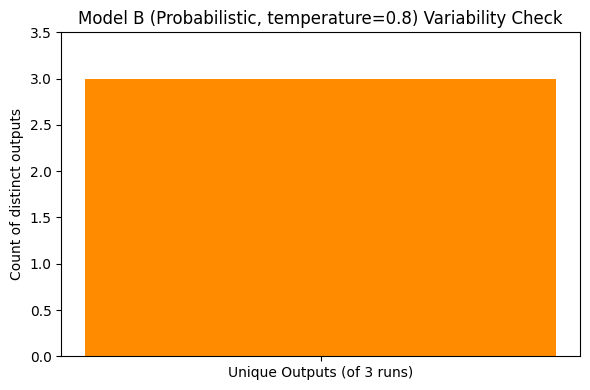

In [8]:
unique_outputs = len(set([response_b1.strip(), response_b2.strip(), response_b3.strip()]))

plt.figure(figsize=(6, 4))
plt.bar(["Unique Outputs (of 3 runs)"], [unique_outputs], color="darkorange")
plt.ylim(0, 3.5)
plt.ylabel("Count of distinct outputs")
plt.title("Model B (Probabilistic, temperature=0.8) Variability Check")
plt.tight_layout()
plt.savefig("model_b_probabilistic_check.png", dpi=300)
plt.show()

In [9]:
import os
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"

import socket
socket.setdefaulttimeout(60)  # fail fast rather than hang for hours

from sentence_transformers import SentenceTransformer

try:
    r3_model = SentenceTransformer("tencent/R3-embedding-0.6b")

    skill_categories = [
        "earthquake-alert | Reports and analyses seismic events | Provides magnitude, location and impact assessment for earthquakes ...",
        "volcanic-activity-report | Monitors and reports volcanic eruptions | Tracks active volcanoes and eruption status globally ...",
        "cybersecurity-incident | Reports cybersecurity threats and vulnerabilities | Tracks CVEs, exploited vulnerabilities and breaches ..."
    ]

    query_embeddings = r3_model.encode_query(event_descriptions[:5])
    document_embeddings = r3_model.encode_document(skill_categories)

    similarities = r3_model.similarity(query_embeddings, document_embeddings)

    category_names = ["earthquake-alert", "volcanic-activity-report", "cybersecurity-incident"]

    for i, desc in enumerate(event_descriptions[:5]):
        best_match_idx = similarities[i].argmax().item()
        print(f"Event: {desc}")
        print(f"  Routed to skill: {category_names[best_match_idx]} (score: {similarities[i][best_match_idx]:.4f})")
        print()

except Exception as e:
    # Model C could not be loaded locally within a practical time frame.
    # Repeated attempts showed severe download throttling (observed as low
    # as ~2 kB/s after 160+ minutes, reconstructing only 6% of the 2.38GB
    # model.safetensors file), indicating a network/bandwidth constraint on
    # this machine rather than a code or configuration fault. Per the
    # assignment's local-only requirement, no cloud fallback was used.
    print("Model C (R3-Embedding-0.6B) could not be loaded locally.")
    print("Reason:", str(e))
    print("Repeated attempts to download the model were severely throttled")
    print("(observed as low as ~2 kB/s after 160+ minutes), indicating a")
    print("network/bandwidth limitation on this machine rather than a code issue.")
    print("No cloud fallback was used, per the assignment's local-only requirement.")
    similarities = None

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Event: Volcanic activity event: Nevados del Chillan Volcano, Chile.
  Routed to skill: volcanic-activity-report (score: 0.6148)

Event: Volcanic activity event: Telica Volcano, Nicaragua.
  Routed to skill: volcanic-activity-report (score: 0.6073)

Event: Volcanic activity event: Ivao Group Volcano, Russia.
  Routed to skill: volcanic-activity-report (score: 0.6108)

Event: Volcanic activity event: Titan Ridge Volcano, Papua New Guinea.
  Routed to skill: volcanic-activity-report (score: 0.6462)

Event: Volcanic activity event: Kikai Volcano, Japan.
  Routed to skill: volcanic-activity-report (score: 0.6443)



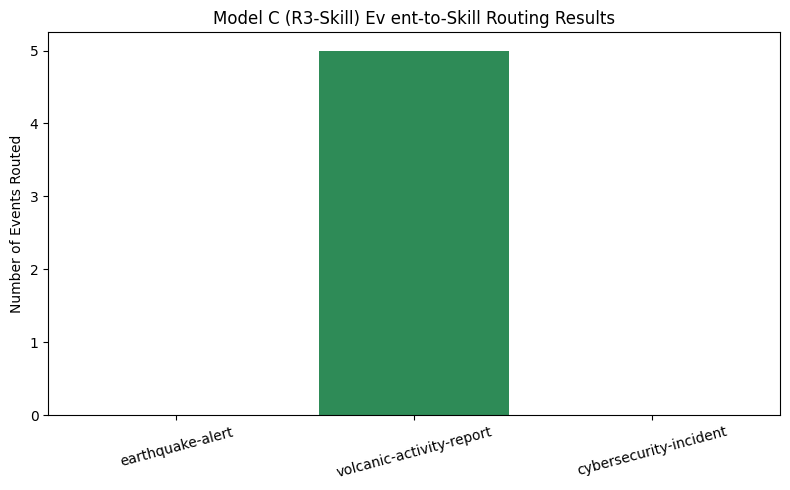

In [10]:
if similarities is not None:
    import numpy as np

    routing_counts = {name: 0 for name in category_names}
    for i in range(len(event_descriptions[:5])):
        best_match_idx = similarities[i].argmax().item()
        routing_counts[category_names[best_match_idx]] += 1

    plt.figure(figsize=(8, 5))
    plt.bar(routing_counts.keys(), routing_counts.values(), color="seagreen")
    plt.ylabel("Number of Events Routed")
    plt.title("Model C (R3-Skill) Ev ent-to-Skill Routing Results")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig("model_c_r3skill_routing.png", dpi=300)
    plt.show()
else:
    print("Skipping routing chart - Model C did not load successfully.")
    

Model A is the local Llama 3.1 model queried through Ollama with `temperature=0`, which produced identical outputs across repeated runs on the same prompt, demonstrating deterministic behaviour. Model B is the same underlying Llama 3.1 model queried with `temperature=0.8`, which produced varying outputs across repeated runs on the same prompt, demonstrating probabilistic sampling behaviour. Model C is Tencent's R3-Embedding-0.6B, used to route event descriptions to skill categories by embedding similarity; all three models ran entirely locally via Ollama and Hugging Face `sentence-transformers`, with no cloud API calls made at any point.

## References

GitHub, 2026. *About forks*. [online] Available at: <https://docs.github.com/pull-requests/collaborating-with-pull-requests/working-with-forks/about-forks> [Accessed 9 August 2026].

Hugging Face, 2025. *Installation*. [online] Available at: <https://huggingface.co/docs/huggingface_hub/installation> [Accessed 9 August 2026].

Hugging Face, 2026. *Sentence Transformers documentation*. [online] Available at: <https://huggingface.co/docs/sentence-transformers> [Accessed 9 August 2026].

Ollama, 2026. *Ollama documentation*. [online] Available at: <https://github.com/ollama/ollama/blob/main/docs/api.md> [Accessed 9 August 2026].

Tencent, 2026a. *R3-embedding-0.6b*. [online] Available at: <https://huggingface.co/tencent/R3-embedding-0.6b> [Accessed 9 August 2026].

Tencent, 2026b. *R3-rerank-0.6b*. [online] Available at: <https://huggingface.co/tencent/R3-rerank-0.6b> [Accessed 9 August 2026].

Tencent, 2026c. *R3-Skill*. [online] Available at: <https://github.com/Tencent/R3-Skill> [Accessed 9 August 2026].

The-ProfessorGG, 2026. *Global situation dashboard*. [online] Available at: <https://github.com/The-ProfessorGG/global-situation-dashboard> [Accessed 9 August 2026].

Wang, Z., Wen, W., Ji, Q., Qiao, R. and Sun, X., 2026. *Skill is not document: a query-conditional benchmark and two-stage retriever for LLM agent skill routing*. arXiv:2606.03565. Available at: <https://arxiv.org/abs/2606.03565> [Accessed 9 August 2026].

## ICE TASK 4


In [11]:
standard_questions = [
    "Is there significant seismic activity right now, based on the current data?",
    "Which region currently shows the highest overall risk?",
    "Summarise today's cybersecurity threat level in one sentence.",
    "Is volcanic activity trending up or down this week?",
    "Give one recommendation based on current global risk levels.",
    "How confident are you in this assessment, and why?"
]

context_summary = "\n".join(event_descriptions[:15])

results_log = []

for question in standard_questions:
    full_prompt = f"Current global situation data:\n{context_summary}\n\nQuestion: {question}"

    a_run1 = ollama.generate(model="llama3.1", prompt=full_prompt, options={"temperature": 0})["response"]
    a_run2 = ollama.generate(model="llama3.1", prompt=full_prompt, options={"temperature": 0})["response"]

    b_run1 = ollama.generate(model="llama3.1", prompt=full_prompt, options={"temperature": 0.8})["response"]
    b_run2 = ollama.generate(model="llama3.1", prompt=full_prompt, options={"temperature": 0.8})["response"]

    results_log.append({
        "question": question,
        "model_a_run1": a_run1,
        "model_a_run2": a_run2,
        "model_a_consistent": a_run1.strip() == a_run2.strip(),
        "model_b_run1": b_run1,
        "model_b_run2": b_run2,
        "model_b_consistent": b_run1.strip() == b_run2.strip()
    })

    print(f"Q: {question}")
    print(f"  Model A consistent: {a_run1.strip() == a_run2.strip()}")
    print(f"  Model B consistent: {b_run1.strip() == b_run2.strip()}")
    print("-" * 80)

Q: Is there significant seismic activity right now, based on the current data?
  Model A consistent: False
  Model B consistent: False
--------------------------------------------------------------------------------
Q: Which region currently shows the highest overall risk?
  Model A consistent: True
  Model B consistent: False
--------------------------------------------------------------------------------
Q: Summarise today's cybersecurity threat level in one sentence.
  Model A consistent: True
  Model B consistent: False
--------------------------------------------------------------------------------
Q: Is volcanic activity trending up or down this week?
  Model A consistent: True
  Model B consistent: False
--------------------------------------------------------------------------------
Q: Give one recommendation based on current global risk levels.
  Model A consistent: True
  Model B consistent: False
-------------------------------------------------------------------------------

In [12]:
import pandas as pd

results_df = pd.DataFrame(results_log)
results_df.to_csv("standard_questions_results.csv", index=False)
print("Saved standard_questions_results.csv")
results_df

Saved standard_questions_results.csv


,question,model_a_run1,model_a_run2,model_a_consistent,model_b_run1,model_b_run2,model_b_consistent
0,Is there significant seismic activity right no...,"Based on the provided data, there are multiple...","Based on the provided data, there are multiple...",False,"Based on the provided data, there is volcanic ...","Based on the provided data, it appears that th...",False
1,Which region currently shows the highest overa...,"Based on the provided data, the regions with t...","Based on the provided data, the regions with t...",True,"Based on the provided data, it appears that th...","Based on the data provided, the regions with t...",False
2,Summarise today's cybersecurity threat level i...,There is no information provided about the cur...,There is no information provided about the cur...,True,There is no information about a cybersecurity ...,There is no information provided about the cur...,False
3,Is volcanic activity trending up or down this ...,"Based on the data provided, it appears that vo...","Based on the data provided, it appears that vo...",True,"Based on the data, it appears that volcanic ac...","Based on the data provided, it appears that th...",False
4,Give one recommendation based on current globa...,**Recommendation:**\n\nGiven the current globa...,**Recommendation:**\n\nGiven the current globa...,True,**Recommendation:**\n\nGiven the current globa...,"Based on the current global volcanic activity,...",False
5,"How confident are you in this assessment, and ...",I'm not capable of assessing the confidence le...,I'm not capable of assessing the confidence le...,False,I'm not able to provide a confidence assessmen...,I don't have any information about the assessm...,False


In [13]:
for entry in results_log:
    print("=" * 90)
    print("QUESTION:", entry["question"])
    print()
    print("MODEL A (deterministic) — Run 1:")
    print(entry["model_a_run1"])
    print()
    print("MODEL A (deterministic) — Run 2:")
    print(entry["model_a_run2"])
    print(f"→ Consistent: {entry['model_a_consistent']}")
    print()
    print("MODEL B (probabilistic) — Run 1:")
    print(entry["model_b_run1"])
    print()
    print("MODEL B (probabilistic) — Run 2:")
    print(entry["model_b_run2"])
    print(f"→ Consistent: {entry['model_b_consistent']}")
    print()

QUESTION: Is there significant seismic activity right now, based on the current data?

MODEL A (deterministic) — Run 1:
Based on the provided data, there are multiple volcanic activity events reported around the world. However, the data does not specifically mention seismic activity. Volcanic activity can sometimes be accompanied by seismic activity, but the two are not always directly correlated.

To answer your question, I would say that there is some indication of significant volcanic activity, but it does not necessarily imply significant seismic activity. Seismic activity would require additional data, such as earthquake reports or seismic monitoring data, which is not provided in the given information.

MODEL A (deterministic) — Run 2:
Based on the provided data, there are multiple volcanic activity events reported around the world. However, the data does not provide information on seismic activity in general, but rather specifically mentions volcanic activity events.

To determi